In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# List of experiments to compare
experiment_names = ["chatgpt_batch_concise",
                    "chatgpt_batch_verbose",
                    "chatgpt_batch_rephrase"]
colors = ['blue', 'green', 'red']          # One colour per run

plt.figure(figsize=(20, 6))

for i, experiment_name in enumerate(experiment_names):
    try:
        df = pd.read_parquet(f"{experiment_name}/attack.parquet")

        # == keep all your original filters ============================= #
        df = df[df["equivalence"]]                                # only equivalent
        df = df[df.apply(lambda r: len(r["aug_steps"]) == len(r["steps"]), axis=1)]
        df = df[df["aug_steps"].str.len() > 0]
        df = df[df["steps"].str.len()     > 0]
        df = df[df['final_answer_correct']]
        df = df[df["split"] == "gsm8k"]
        # =============================================================== #

        print(f"{experiment_name}: {len(df)}/{len(df)} samples after filtering")

        # -----------------------------------------------------------------
        # 1.  Gather *relative* change in length for every aligned step
        # -----------------------------------------------------------------
        length_deltas_pct = []       # (aug-orig)/orig – unit-free %
        length_deltas_abs = []       # aug-orig – absolute char diff

        for _, row in df.iterrows():
            for o_step, a_step in zip(row["steps"], row["aug_steps"]):
                o_len = len(o_step)
                a_len = len(a_step)
                if o_len == 0:               # defensive – should not happen
                    continue
                length_deltas_pct.append((a_len - o_len) / o_len)
                length_deltas_abs.append(a_len - o_len)

        # -----------------------------------------------------------------
        # 2.  Choose which measure to plot
        #     – Uncomment ONE of the next two lines
        # -----------------------------------------------------------------
        deltas = np.array(length_deltas_pct)   # relative (% of original)
        #deltas = np.array(length_deltas_abs)  # absolute (# of characters)

        # -----------------------------------------------------------------
        # 3.  Plot histogram + KDE
        # -----------------------------------------------------------------
        plt.hist(deltas,
                 bins=40,
                 density=True,
                 alpha=0.25,
                 edgecolor=colors[i],
                 color=colors[i],
                 label=f"{experiment_name} histogram")

        kde = stats.gaussian_kde(deltas)
        x = np.linspace(deltas.min(), deltas.max(), 300)
        plt.plot(x, kde(x),
                 color=colors[i],
                 lw=2,
                 label=f"{experiment_name}  (μ = {deltas.mean():.3f})")

        # Add per-run stats in the margin
        ax = plt.gca()
        ax.text(0.02,
                0.95 - i*0.15,
                f"{experiment_name}\n"
                f"  mean : {deltas.mean():.3f}\n"
                f"  median: {np.median(deltas):.3f}\n"
                f"  σ     : {deltas.std():.3f}",
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor=colors[i]))

    except Exception as e:
        print(f"Error processing {experiment_name}: {e}")

plt.title("Distribution of Changes in Step Lengths (Augmented – Original)")
plt.xlabel("Relative change in length"  # replace wording if you show absolute values
           " (fraction of original)")
plt.ylabel("Density")
plt.axvline(0, color='k', ls='--', lw=1, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

: 

## Joint KDE Plot

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import gaussian_kde

def joint_kde_plot(x, y, n_levels=15, bins=30, title=None):
    """
    x, y          : 1‑D numpy arrays of equal length
    n_levels      : number of contour levels for the 2‑D KDE
    bins          : histogram bins for the marginals
    """
    # ── layout: top = x‑marginal, right = y‑marginal ──────────────────────
    fig = plt.figure(figsize=(5, 5))
    gs  = gridspec.GridSpec(2, 2,
                            width_ratios=[4, 1],
                            height_ratios=[1, 4],
                            wspace=0.05, hspace=0.05)

    ax_top   = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # ── 2‑D KDE ───────────────────────────────────────────────────────────
    xx = np.linspace(-0.2, 0.2, 200)
    yy = np.linspace(min(y), max(y), 200)
    XX, YY = np.meshgrid(xx, yy)
    kde     = gaussian_kde([x, y])
    ZZ      = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

    ax_joint.contourf(XX, YY, ZZ, levels=n_levels)
    ax_joint.set_xlabel("delta reward")
    ax_joint.set_ylabel("delta cumulative step length (log)")
    ax_joint.set_xlim(-0.2, 0.2)

    ax_top.hist(x, bins=bins, density=True, alpha=0.6)
    ax_right.hist(y, bins=bins, density=True,
                  orientation="horizontal", alpha=0.6)

    ax_top.set_xticks([]) 
    ax_top.set_yticks([])

    ax_right.set_xticks([]) 
    ax_right.set_yticks([])

    if title:
        fig.suptitle(title)
    
    plt.show()

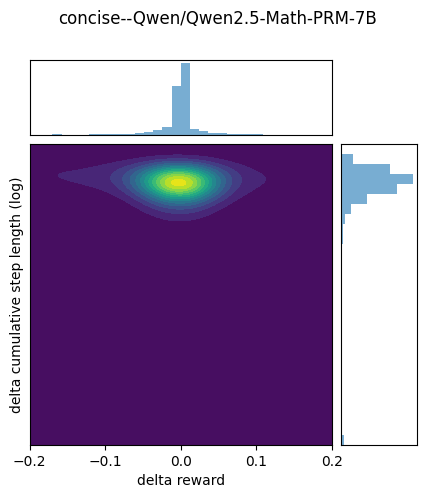

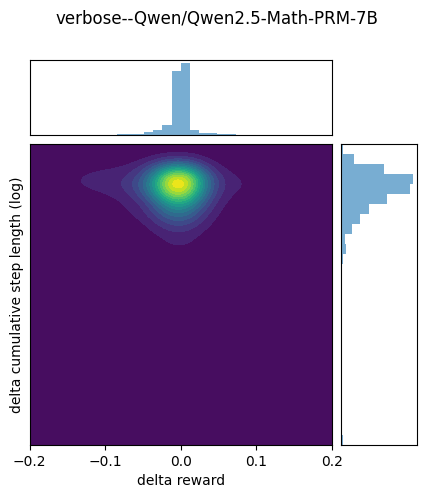

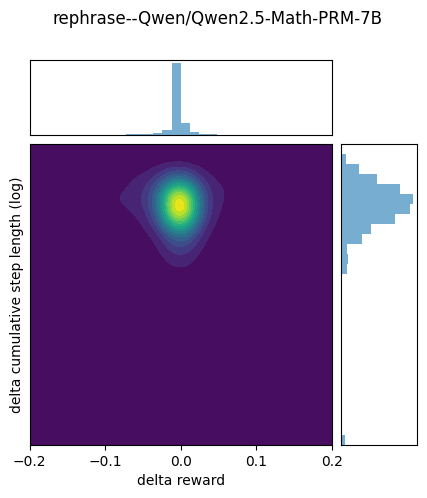

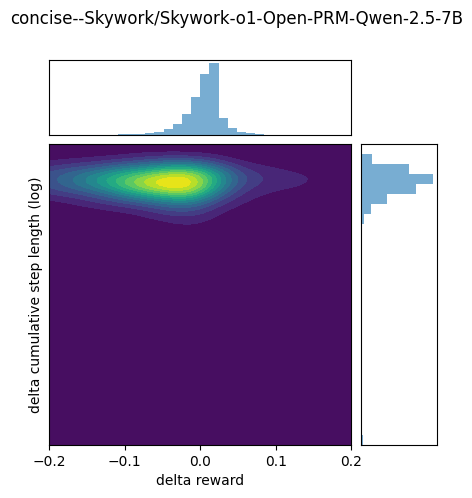

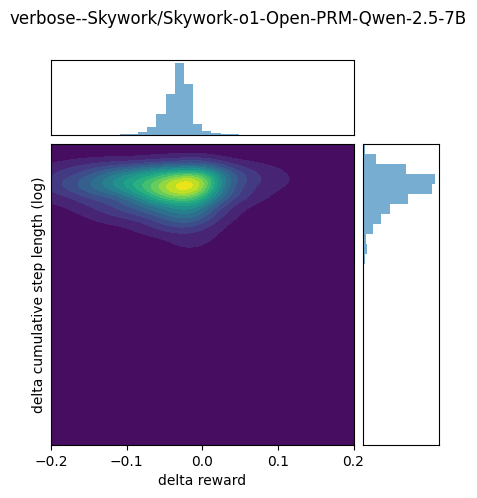

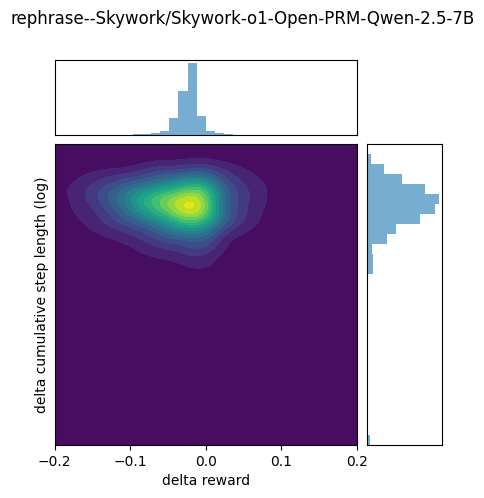

In [17]:
EXPERIMENT_NAMES = ["chatgpt_batch_concise", "chatgpt_batch_verbose", "chatgpt_batch_rephrase"]
FINAL_ANSWER_CORRECT = None # True or False or None
SPLIT = "olympiadbench" # "gsm8k" or "math" or "olympiadbench" or "omnimath" or "all"
MODELS = ["Qwen/Qwen2.5-Math-PRM-7B", "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B"]
flatten_to_numpy = lambda _list: np.array([item for sublist in _list for item in sublist])

for model in MODELS:
    for exp in EXPERIMENT_NAMES:
        df_sample = pd.read_parquet(f"{exp}/attack.parquet")

        # Filter data
        ## Equivalence and step length checks
        df_filtered = df_sample[df_sample["equivalence"] == True]
        df_filtered = df_filtered[df_filtered.apply(lambda row: len(row[model.split("/")[-1]]) == len(row[model+"--aug_rewards"]), axis=1)]
        ## Augmented steps and original steps are non-empty
        df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
        df_filtered = df_filtered[df_filtered["steps"].apply(lambda x: len(x) > 0)]
        ## Final answer is correct
        if FINAL_ANSWER_CORRECT is not None:
            df_filtered = df_filtered[df_filtered['final_answer_correct']==FINAL_ANSWER_CORRECT]

        ## Decide splitchatgpt_batch_concise
        if SPLIT != "all":
            df_filtered = df_filtered[df_filtered["split"] == SPLIT]

        ## Filtering done, now calculating deltas
        original_rewards_skywork = df_filtered[model.split("/")[-1]].tolist()
        augmented_rewards_skywork = df_filtered[model+"--aug_rewards"].tolist()
        ## Calculate deltas
        reward_deltas_skywork = flatten_to_numpy(augmented_rewards_skywork) - flatten_to_numpy(original_rewards_skywork)

        ## Calculate log step lengths
        original_step_cumulative_lengths = [np.cumsum([len(step) for step in steps]) for steps in df_filtered["steps"].tolist()]
        augmented_step_cumulative_lengths = [np.cumsum([len(step) for step in steps]) for steps in df_filtered["aug_steps"].tolist()]
        ## Calculate deltas
        step_deltas_skywork = np.log(np.abs(flatten_to_numpy(augmented_step_cumulative_lengths) - flatten_to_numpy(original_step_cumulative_lengths)) + 1e-5)

        ## Plot joint kde plot
        joint_kde_plot(reward_deltas_skywork, step_deltas_skywork, title=exp.split("_")[-1] + "--" + model)
